# 🧩 02 — Feature Engineering Quality Check

This notebook verifies whether the feature-engineered Taiwan air quality dataset
(e.g., Taiwan.csv or per-county files) meets all feature integrity and consistency standards
before model training.

## 🧠 01 — Notebook Metadata
Basic setup information and environment initialization for this analysis.

In [21]:
import pandas as pd
from src.modeling.train_baseline import load_cleaned_data
from src.modeling.feature_engineering import add_rolling_features
import matplotlib.pyplot as plt
import seaborn as sns

## 🧱 02 — Load Processed Data

Load the cleaned dataset using load_cleaned_data and check:

- File `path` and `size`

- `Shape` and column structure

- Preview first few rows

In [4]:
df = load_cleaned_data("Taiwan")

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ Read CSV successfully! Shape: (5866841, 25)


In [5]:
df = add_rolling_features(df)

⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.


In [6]:
df.shape

(5866841, 39)

In [7]:
df.dtypes

date                datetime64[ns]
sitename                    object
county                      object
aqi                        float64
status                      object
so2                        float64
co                         float64
o3                         float64
o3_8hr                     float64
pm10                       float64
pm2.5                      float64
no2                        float64
nox                        float64
no                         float64
windspeed                  float64
winddirec                  float64
co_8hr                     float64
longitude                  float64
latitude                   float64
year                         int64
month                        int64
day                          int64
weekday                      int64
hour                         int64
season                      object
so2_rolling_3d             float64
so2_rolling_7d             float64
co_rolling_3d              float64
co_rolling_7d       

In [8]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
5866840,2016-11-25 13:00:00,Qianjin,Kaohsiung_City,84.0,Moderate,2.9,0.47,76.0,34.0,86.0,...,76.0,76.0,86.0,86.0,42.0,42.0,14.0,14.0,0.9,0.9
5866785,2016-11-25 13:00:00,Mailiao,Yunlin_County,49.0,Good,3.8,0.31,56.0,30.0,82.0,...,56.0,56.0,82.0,82.0,17.0,17.0,9.5,9.5,2.4,2.4
5866786,2016-11-25 13:00:00,Keelung,Keelung_City,30.0,Good,1.1,0.22,37.0,35.0,14.0,...,37.0,37.0,14.0,14.0,4.0,4.0,3.0,3.0,1.7,1.7
5866787,2016-11-25 13:00:00,Xizhi,New_Taipei_City,23.0,Good,0.7,0.26,28.0,27.0,21.0,...,28.0,28.0,21.0,21.0,5.0,5.0,11.0,11.0,4.0,4.0
5866788,2016-11-25 13:00:00,Wanli,New_Taipei_City,34.0,Good,1.2,0.20,42.0,40.0,31.0,...,42.0,42.0,31.0,31.0,2.0,2.0,2.7,2.7,1.6,1.6


## 🕒 03 — Time Features Validation

Verify that all time-based columns were generated correctly during feature engineering:

- `year`, `month`, `day`, `weekday`, `hour`

- `season` classification

- Reasonable numeric ranges and no missing values

In [9]:
df[["year", "month", "day", "weekday", "hour"]].nunique()

year        9
month      12
day        31
weekday     7
hour       24
dtype: int64

In [10]:
df["season"].value_counts()

season
Spring    1613117
Winter    1521528
Summer    1487742
Autumn    1244454
Name: count, dtype: int64

In [11]:
df[["year", "month", "day", "weekday", "hour", "season"]].isna().any()

year       False
month      False
day        False
weekday    False
hour       False
season     False
dtype: bool

## 📈 04 — Rolling Features Validation

Check that rolling mean features (3-day, 7-day, etc.) exist and behave as expected:

- Verify columns like `pm2.5_rolling_3d`, `pm2.5_rolling_7d`, `co_rolling_3d`

- Inspect descriptive statistics

- Visualize trend smoothing over time

In [12]:
[col for col in df.columns if "rolling" in col]

['so2_rolling_3d',
 'so2_rolling_7d',
 'co_rolling_3d',
 'co_rolling_7d',
 'o3_rolling_3d',
 'o3_rolling_7d',
 'pm10_rolling_3d',
 'pm10_rolling_7d',
 'pm2.5_rolling_3d',
 'pm2.5_rolling_7d',
 'no2_rolling_3d',
 'no2_rolling_7d',
 'no_rolling_3d',
 'no_rolling_7d']

In [16]:
df[["pm2.5", "pm2.5_rolling_3d", "pm2.5_rolling_7d"]].describe()

,pm2.5,pm2.5_rolling_3d,pm2.5_rolling_7d
count,5.866767e+06,5.866767e+06,5.866767e+06
mean,1.681421e+01,1.681428e+01,1.681438e+01
std,1.252132e+01,1.205223e+01,1.158589e+01
min,-9.990000e+02,-3.209627e+02,-1.254126e+02
25%,8.000000e+00,8.333333e+00,8.571429e+00
50%,1.400000e+01,1.366667e+01,1.371429e+01
75%,2.200000e+01,2.233333e+01,2.214286e+01
max,1.000000e+03,4.380000e+02,3.242686e+02


Text(0.5, 1.0, 'Rolling Mean vs Raw PM2.5')

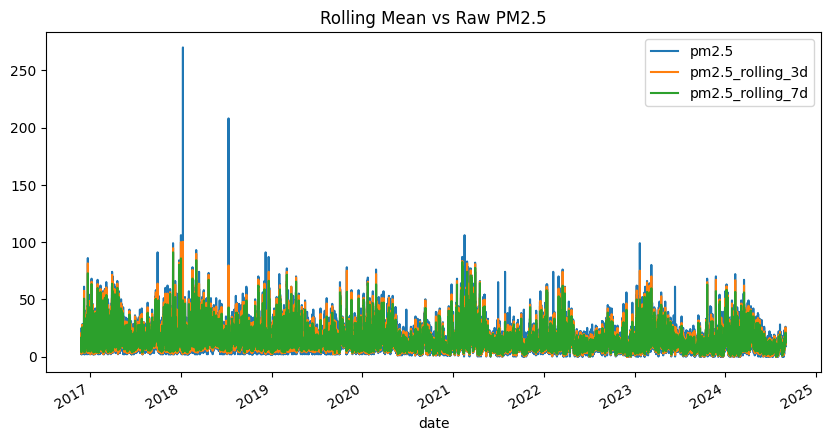

In [18]:
site_df = df[df["sitename"] == "Taoyuan"].set_index("date")
site_df[["pm2.5", "pm2.5_rolling_3d", "pm2.5_rolling_7d"]].plot(figsize=(10, 5))
plt.title("Rolling Mean vs Raw PM2.5")

## 🔗 05 — Feature Correlation Analysis

Assess potential multicollinearity among pollutant and rolling features:

- Compute correlation matrix (`df.corr()`)

- Visualize with heatmap (`sns.heatmap()`)

- Identify highly correlated pairs (>0.95)

In [23]:
corr = df.corr(numeric_only=True)
corr

,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,no2,nox,no,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
aqi,1.000000,0.265965,0.069444,0.291252,0.352877,0.769454,0.856031,0.348622,0.224207,0.032861,...,0.310468,0.339791,0.812047,0.841179,0.908376,0.935933,0.368685,0.389580,0.038756,0.043291
so2,0.265965,1.000000,0.052480,0.030350,0.009788,0.302598,0.296437,0.328526,0.270787,0.140321,...,0.021058,0.005109,0.296664,0.282546,0.291833,0.277088,0.316965,0.291782,0.139055,0.122894
co,0.069444,0.052480,1.000000,-0.035789,-0.015020,0.068625,0.079149,0.161313,0.176784,0.148304,...,-0.034936,-0.026817,0.066290,0.062564,0.076797,0.072110,0.155582,0.142445,0.142523,0.126066
o3,0.291252,0.030350,-0.035789,1.000000,0.737087,0.200213,0.160655,-0.281339,-0.299689,-0.239732,...,0.956290,0.799878,0.204518,0.197257,0.173075,0.180350,-0.261804,-0.219596,-0.210263,-0.158099
o3_8hr,0.352877,0.009788,-0.015020,0.737087,1.000000,0.232679,0.168025,-0.124387,-0.216952,-0.277199,...,0.850844,0.980655,0.242680,0.249717,0.178618,0.195147,-0.165784,-0.213810,-0.295501,-0.286590
pm10,0.769454,0.302598,0.068625,0.200213,0.232679,1.000000,0.796114,0.355903,0.244773,0.062736,...,0.206650,0.219732,0.961530,0.895445,0.791746,0.760032,0.356519,0.343432,0.065039,0.059127
pm2.5,0.856031,0.296437,0.079149,0.160655,0.168025,0.796114,1.000000,0.403156,0.271813,0.061515,...,0.155969,0.158618,0.793589,0.765228,0.956351,0.896068,0.411595,0.405107,0.064714,0.057699
no2,0.348622,0.328526,0.161313,-0.281339,-0.124387,0.355903,0.403156,1.000000,0.878647,0.527024,...,-0.253168,-0.174789,0.346266,0.327405,0.391357,0.365594,0.954330,0.860075,0.521691,0.489204
nox,0.224207,0.270787,0.176784,-0.299689,-0.216952,0.244773,0.271813,0.878647,1.000000,0.868588,...,-0.289148,-0.244476,0.231996,0.212879,0.259288,0.237266,0.840631,0.763229,0.830533,0.745104
no,0.032861,0.140321,0.148304,-0.239732,-0.277199,0.062736,0.061515,0.527024,0.868588,1.000000,...,-0.250880,-0.254279,0.050117,0.035800,0.051413,0.039170,0.504829,0.464619,0.934759,0.816672


<Axes: >

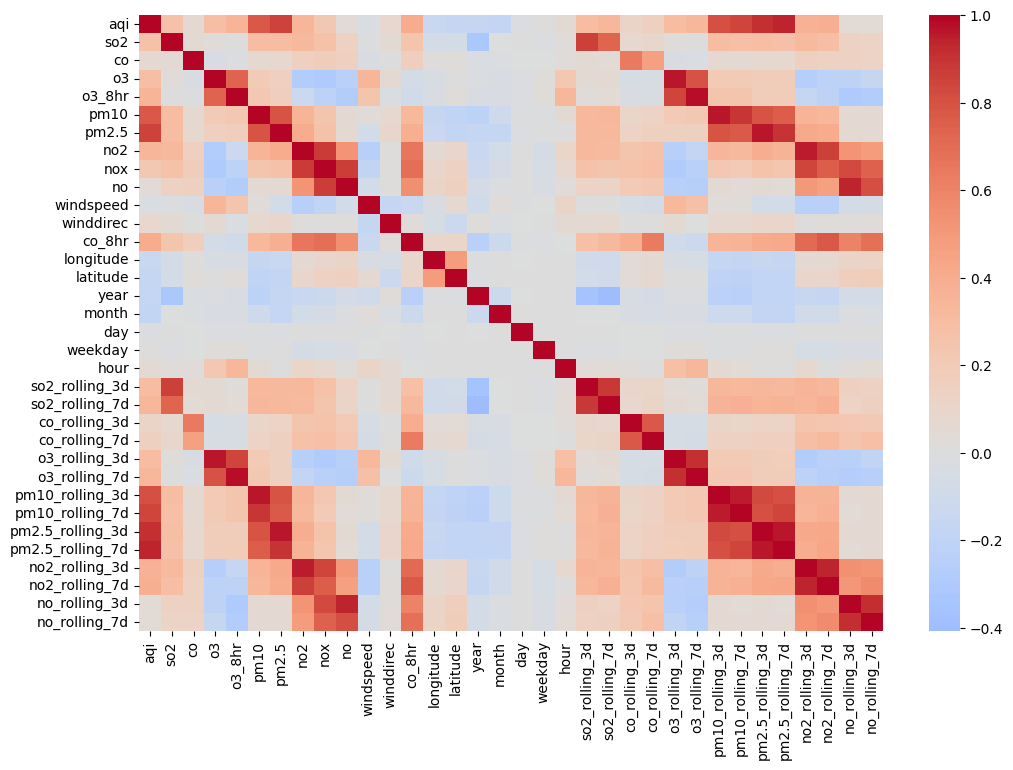

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)

## 📊 06 — Feature Distribution & Outliers

Evaluate statistical distributions for numerical features:

- Use `df.describe()` for summary stats

- Draw `histograms` or `boxplots` for pollutants

- Check for unrealistic outliers (e.g., negative or extreme pollution values)

In [25]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,5866841,2020-11-21 06:05:38.886565888,2016-11-25 13:00:00,2019-02-04 01:00:00,2021-01-28 18:00:00,2022-09-07 11:00:00,2024-08-31 23:00:00,NaN
aqi,5866841.0,54.225395,0.0,32.0,47.0,70.0,500.0,29.693463
so2,5866820.0,1.993169,-999.0,1.0,1.7,2.5,255.4,1.857285
co,5866820.0,0.336553,-999.0,0.19,0.28,0.41,38.58,1.192943
o3,5866820.0,30.208443,-999.0,16.0,28.0,41.5,410.0,18.122772
o3_8hr,5721081.0,30.343921,-1.0,18.0,29.0,41.0,135.8,15.847086
pm10,5866533.0,34.352239,-999.0,18.0,29.0,45.0,1407.0,24.039525
pm2.5,5866767.0,16.814213,-999.0,8.0,14.0,22.0,1000.0,12.52132
no2,5866816.0,11.240364,-27.78,5.1,9.1,15.0,351.05,8.600151
nox,5705641.0,14.713603,-1.6,6.2,10.8,18.0,431.0,14.881657


array([[<Axes: title={'center': 'pm2.5'}>,
        <Axes: title={'center': 'pm10'}>,
        <Axes: title={'center': 'so2'}>],
       [<Axes: title={'center': 'co'}>, <Axes: title={'center': 'o3'}>,
        <Axes: title={'center': 'no'}>],
       [<Axes: title={'center': 'no2'}>, <Axes: title={'center': 'nox'}>,
        <Axes: >]], dtype=object)

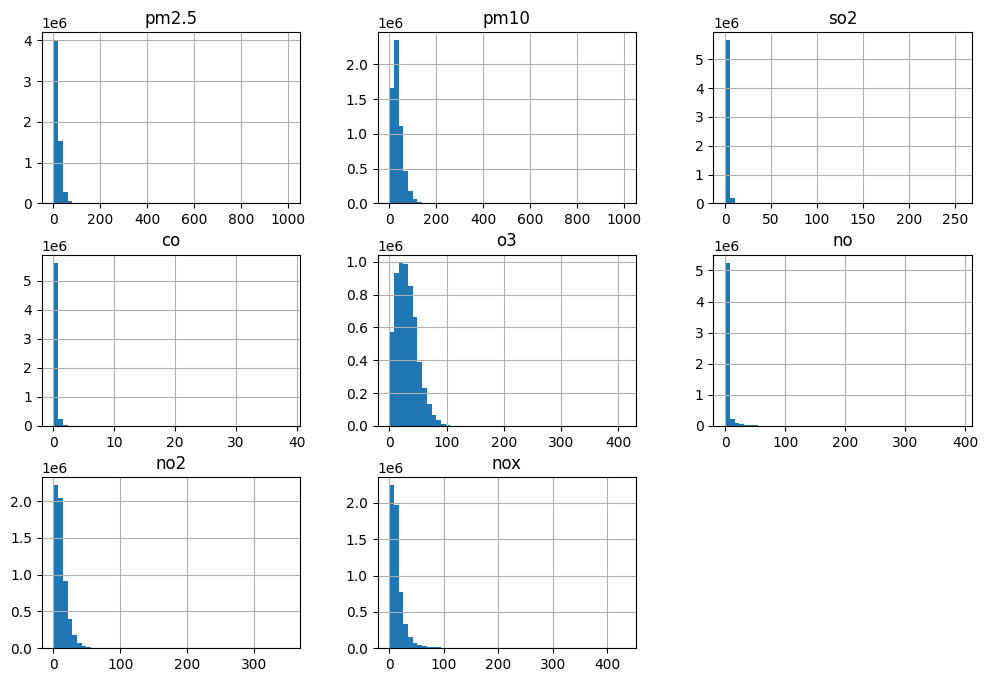

In [44]:
cols = ["pm2.5", "pm10", "so2", "co", "o3", "no", "no2", "nox"]
for c in cols:
    if c in df.columns:
        df[c] = df[c].clip(lower=0, upper=1000)

df[cols].hist(bins=50, figsize=(12, 8))

<Axes: xlabel='season', ylabel='pm2.5'>

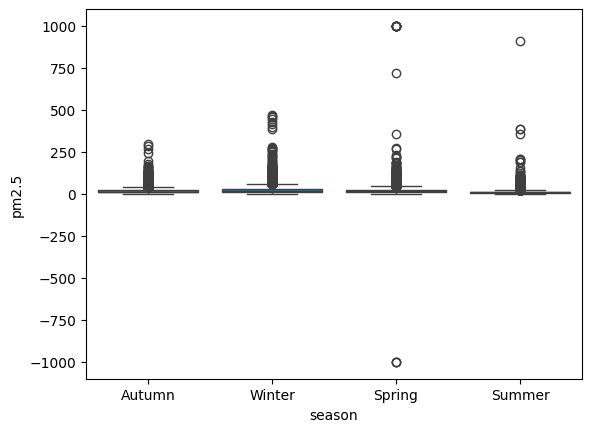

In [28]:
sns.boxplot(data=df, x="season", y="pm2.5")

## ⚙️ 07 — Missing Values & Data Types

Confirm that all features have appropriate data types and no excessive missing values:

- Missing value ratio < 1% for key pollutants

- `object` columns limited to categorical features (`county`, `sitename`, `season`)

- All numeric features are `float64` or `int64`

In [30]:
(df.isna().mean()*100).sort_values(ascending=False)

longitude           15.913368
latitude            15.913368
no                   2.753270
nox                  2.747646
o3_8hr               2.484472
status               2.305943
co_8hr               1.646389
no_rolling_3d        0.975414
no_rolling_7d        0.480770
pm10_rolling_3d      0.005250
pm10_rolling_7d      0.005250
pm10                 0.005250
pm2.5                0.001261
pm2.5_rolling_7d     0.001261
pm2.5_rolling_3d     0.001261
no2_rolling_7d       0.000426
no2_rolling_3d       0.000426
no2                  0.000426
co_rolling_3d        0.000358
co                   0.000358
so2                  0.000358
o3_rolling_7d        0.000358
co_rolling_7d        0.000358
so2_rolling_3d       0.000358
so2_rolling_7d       0.000358
o3                   0.000358
o3_rolling_3d        0.000358
aqi                  0.000000
date                 0.000000
sitename             0.000000
county               0.000000
weekday              0.000000
day                  0.000000
month     

In [31]:
df.dtypes.value_counts()

float64           29
int64              5
object             4
datetime64[ns]     1
Name: count, dtype: int64

In [32]:
df.select_dtypes(include="object").columns

Index(['sitename', 'county', 'status', 'season'], dtype='object')

In [33]:
df.select_dtypes(include=["float64", "int64"]).columns

Index(['aqi', 'so2', 'co', 'o3', 'o3_8hr', 'pm10', 'pm2.5', 'no2', 'nox', 'no',
       'windspeed', 'winddirec', 'co_8hr', 'longitude', 'latitude', 'year',
       'month', 'day', 'weekday', 'hour', 'so2_rolling_3d', 'so2_rolling_7d',
       'co_rolling_3d', 'co_rolling_7d', 'o3_rolling_3d', 'o3_rolling_7d',
       'pm10_rolling_3d', 'pm10_rolling_7d', 'pm2.5_rolling_3d',
       'pm2.5_rolling_7d', 'no2_rolling_3d', 'no2_rolling_7d', 'no_rolling_3d',
       'no_rolling_7d'],
      dtype='object')

## 🌡️ 08 — Feature–Target Relationship

Explore linear correlation between each feature and `AQI`:

- Compute correlation coefficients

- Identify top features most predictive of `AQI`

- Visualize top contributors with bar chart

In [34]:
corr = df.corr(numeric_only=True)
corr

,aqi,so2,co,o3,o3_8hr,pm10,pm2.5,no2,nox,no,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
aqi,1.000000,0.265965,0.069444,0.291252,0.352877,0.769454,0.856031,0.348622,0.224207,0.032861,...,0.310468,0.339791,0.812047,0.841179,0.908376,0.935933,0.368685,0.389580,0.038756,0.043291
so2,0.265965,1.000000,0.052480,0.030350,0.009788,0.302598,0.296437,0.328526,0.270787,0.140321,...,0.021058,0.005109,0.296664,0.282546,0.291833,0.277088,0.316965,0.291782,0.139055,0.122894
co,0.069444,0.052480,1.000000,-0.035789,-0.015020,0.068625,0.079149,0.161313,0.176784,0.148304,...,-0.034936,-0.026817,0.066290,0.062564,0.076797,0.072110,0.155582,0.142445,0.142523,0.126066
o3,0.291252,0.030350,-0.035789,1.000000,0.737087,0.200213,0.160655,-0.281339,-0.299689,-0.239732,...,0.956290,0.799878,0.204518,0.197257,0.173075,0.180350,-0.261804,-0.219596,-0.210263,-0.158099
o3_8hr,0.352877,0.009788,-0.015020,0.737087,1.000000,0.232679,0.168025,-0.124387,-0.216952,-0.277199,...,0.850844,0.980655,0.242680,0.249717,0.178618,0.195147,-0.165784,-0.213810,-0.295501,-0.286590
pm10,0.769454,0.302598,0.068625,0.200213,0.232679,1.000000,0.796114,0.355903,0.244773,0.062736,...,0.206650,0.219732,0.961530,0.895445,0.791746,0.760032,0.356519,0.343432,0.065039,0.059127
pm2.5,0.856031,0.296437,0.079149,0.160655,0.168025,0.796114,1.000000,0.403156,0.271813,0.061515,...,0.155969,0.158618,0.793589,0.765228,0.956351,0.896068,0.411595,0.405107,0.064714,0.057699
no2,0.348622,0.328526,0.161313,-0.281339,-0.124387,0.355903,0.403156,1.000000,0.878647,0.527024,...,-0.253168,-0.174789,0.346266,0.327405,0.391357,0.365594,0.954330,0.860075,0.521691,0.489204
nox,0.224207,0.270787,0.176784,-0.299689,-0.216952,0.244773,0.271813,0.878647,1.000000,0.868588,...,-0.289148,-0.244476,0.231996,0.212879,0.259288,0.237266,0.840631,0.763229,0.830533,0.745104
no,0.032861,0.140321,0.148304,-0.239732,-0.277199,0.062736,0.061515,0.527024,0.868588,1.000000,...,-0.250880,-0.254279,0.050117,0.035800,0.051413,0.039170,0.504829,0.464619,0.934759,0.816672


In [41]:
aqi_corr = corr["aqi"][1:].sort_values(ascending=False)
aqi_corr

pm2.5_rolling_7d    0.935933
pm2.5_rolling_3d    0.908376
pm2.5               0.856031
pm10_rolling_7d     0.841179
pm10_rolling_3d     0.812047
pm10                0.769454
co_8hr              0.401524
no2_rolling_7d      0.389580
no2_rolling_3d      0.368685
o3_8hr              0.352877
no2                 0.348622
so2_rolling_7d      0.344737
o3_rolling_7d       0.339791
o3_rolling_3d       0.310468
so2_rolling_3d      0.308087
o3                  0.291252
so2                 0.265965
nox                 0.224207
co_rolling_7d       0.150807
co_rolling_3d       0.114791
winddirec           0.085891
co                  0.069444
hour                0.053330
no_rolling_7d       0.043291
no_rolling_3d       0.038756
no                  0.032861
weekday             0.013381
day                -0.018897
windspeed          -0.024703
longitude          -0.146445
latitude           -0.165174
year               -0.168645
month              -0.176908
Name: aqi, dtype: float64

<Axes: >

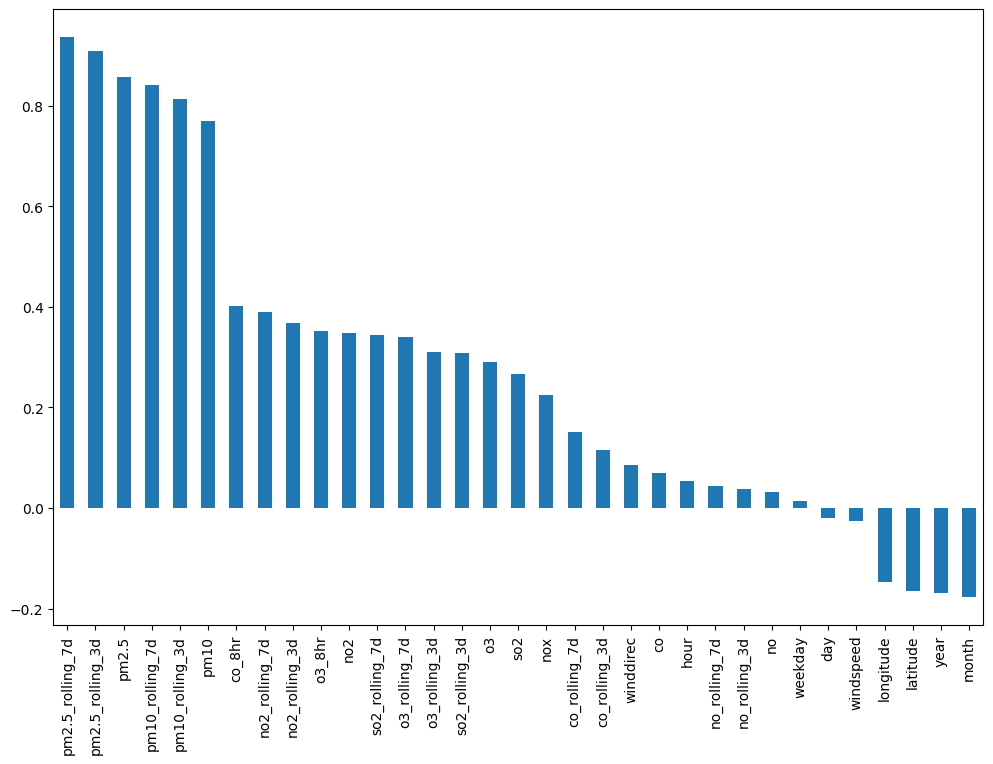

In [42]:
aqi_corr.plot(kind="bar",figsize=(12,8))

## ✅ 09 — Summary & Conclusions

Summarize the findings of the feature validation:

✅ Time features generated correctly

✅ Rolling features smoothed as expected

✅ No missing or misaligned data

⚠️ Some pollutant features highly correlated (expected)

✅ Dataset ready for baseline modeling